# Motivation: per-timer measured-time spread (0616 stencil filt data)

Violin of raw measured times (`met.csv` = TM) per timer per host, from the 20260616 stencil
dsub run used by `plot_entry_filt.0616.ipynb`. Drops `likwid` + `tsc_native`; drops the real
`cntvct` and renames `cntvcto`->`cntvct` (shown as CNTVCT). Timer labels are mapped for display.
Run with the `xfold-scripts` kernel.

In [1]:
import os
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_ROOT = '/astrum/home/hpchzy/code/data'
DATE_BASE = '20260616'
OUTPUT = 'output_stencil_filt_dsub'
SHUFFLE_SELECT = 'shuffle1'

# which kernel / grid size to show (one panel per host)
KERNEL = 'jacobi2d5p'
SIZE = 512
HOSTS = ['cgnr6760pn2', 'camd9554n1', 'c920bn3']

# timers removed entirely; cntvcto is renamed to cntvct (CNTVCT) afterwards
DROP_TIMERS = {'likwid', 'tsc_native', 'cntvct'}

SAMPLE_PER_TIMER = 20000   # subsample met.csv per (host, timer) for the violins
QUANTILE_TRIM = 0.995      # drop the upper tail before plotting

# ---- font sizes (tune here) ----
TITLE_FONTSIZE  = 15   # host panel title
XLABEL_FONTSIZE = 13   # x-axis label (Measured time (ns))
YLABEL_FONTSIZE = 13   # y-axis label (Timer)
XTICK_FONTSIZE  = 11   # x tick numbers (ns)
YTICK_FONTSIZE  = 11   # y tick labels (timer names)

TIMER_LABELS = {
    'tsc': 'TSC',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'cntvct': 'CNTVCT',
}
TIMER_COLORS = {
    'cgt': '#ff7f0e', 'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c', 'mpi_wtime': '#2ca02c',
    'papi': '#d62728', 'papix6': '#9467bd',
    'tsc': '#1f77b4', 'cntvct': '#e377c2',
}
# top-to-bottom order on the y-axis (native timer first)
TIMER_ORDER = ['tsc', 'cntvct', 'clock_gettime', 'cgt', 'mpi_wtime', 'wtime', 'papi', 'papix6']

HOST_NAME_MAP = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n1': 'AMD EPYC 9554',
    'camd9554n2': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}


def timer_label(t):
    return TIMER_LABELS.get(t, t.upper().replace('_', '-'))


def latest_run_root(host):
    base = Path(f'{DATA_ROOT}/{DATE_BASE}/{host}/{OUTPUT}')
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / SHUFFLE_SELECT
        if root.exists():
            return root
    return None

In [3]:
records = []
for host in HOSTS:
    root = latest_run_root(host)
    if root is None:
        print(f'no run root for {host}')
        continue
    for folder in sorted(root.glob(f'{KERNEL}_*_np*_size{SIZE}_*_filt')):
        m = re.match(rf'{re.escape(KERNEL)}_(?P<timer>.+?)_np\d+_size{SIZE}_', folder.name)
        if not m:
            continue
        timer = m.group('timer')
        if timer in DROP_TIMERS:
            continue
        met = folder / 'met.csv'
        if not met.exists():
            continue
        vals = pd.to_numeric(pd.read_csv(met, header=None).iloc[:, 0], errors='coerce').dropna()
        if len(vals) > SAMPLE_PER_TIMER:
            vals = vals.sample(n=SAMPLE_PER_TIMER, random_state=42)
        rec = pd.DataFrame({'ns': vals.to_numpy()})
        rec['timer'] = timer
        rec['host'] = host
        records.append(rec)

df = pd.concat(records, ignore_index=True)
# keep cntvcto, rename to cntvct (displayed as CNTVCT); the real cntvct was already dropped
df['timer'] = df['timer'].replace('cntvcto', 'cntvct')
df['timer_label'] = df['timer'].map(timer_label).fillna(df['timer'])
print(df.groupby(['host', 'timer']).size().to_string())
df.head()

host         timer 
c920bn3      cgt       20000
             cntvct    20000
             papi      20000
             papix6    20000
             wtime     20000
camd9554n1   cgt       20000
             papi      20000
             papix6    20000
             tsc       20000
             wtime     20000
cgnr6760pn2  cgt       20000
             papi      20000
             papix6    20000
             tsc       20000
             wtime     20000


,ns,timer,host,timer_label
0,1386,cgt,cgnr6760pn2,clock_gettime
1,1071,cgt,cgnr6760pn2,clock_gettime
2,901,cgt,cgnr6760pn2,clock_gettime
3,810,cgt,cgnr6760pn2,clock_gettime
4,566,cgt,cgnr6760pn2,clock_gettime


In [4]:
# drop the upper tail per (host, timer) so the violins are readable
thr = df.groupby(['host', 'timer'])['ns'].transform(lambda s: s.quantile(QUANTILE_TRIM))
df_trim = df[df['ns'] <= thr].copy()
print(f'rows: {len(df)} -> {len(df_trim)} after {QUANTILE_TRIM:g} trim')
df_trim.head()

rows: 300000 -> 298512 after 0.995 trim


,ns,timer,host,timer_label
0,1386,cgt,cgnr6760pn2,clock_gettime
1,1071,cgt,cgnr6760pn2,clock_gettime
2,901,cgt,cgnr6760pn2,clock_gettime
3,810,cgt,cgnr6760pn2,clock_gettime
4,566,cgt,cgnr6760pn2,clock_gettime


saved: /astrum/home/hpchzy/code/TacVar/utils/motivation_0616_jacobi2d5p_size512.png


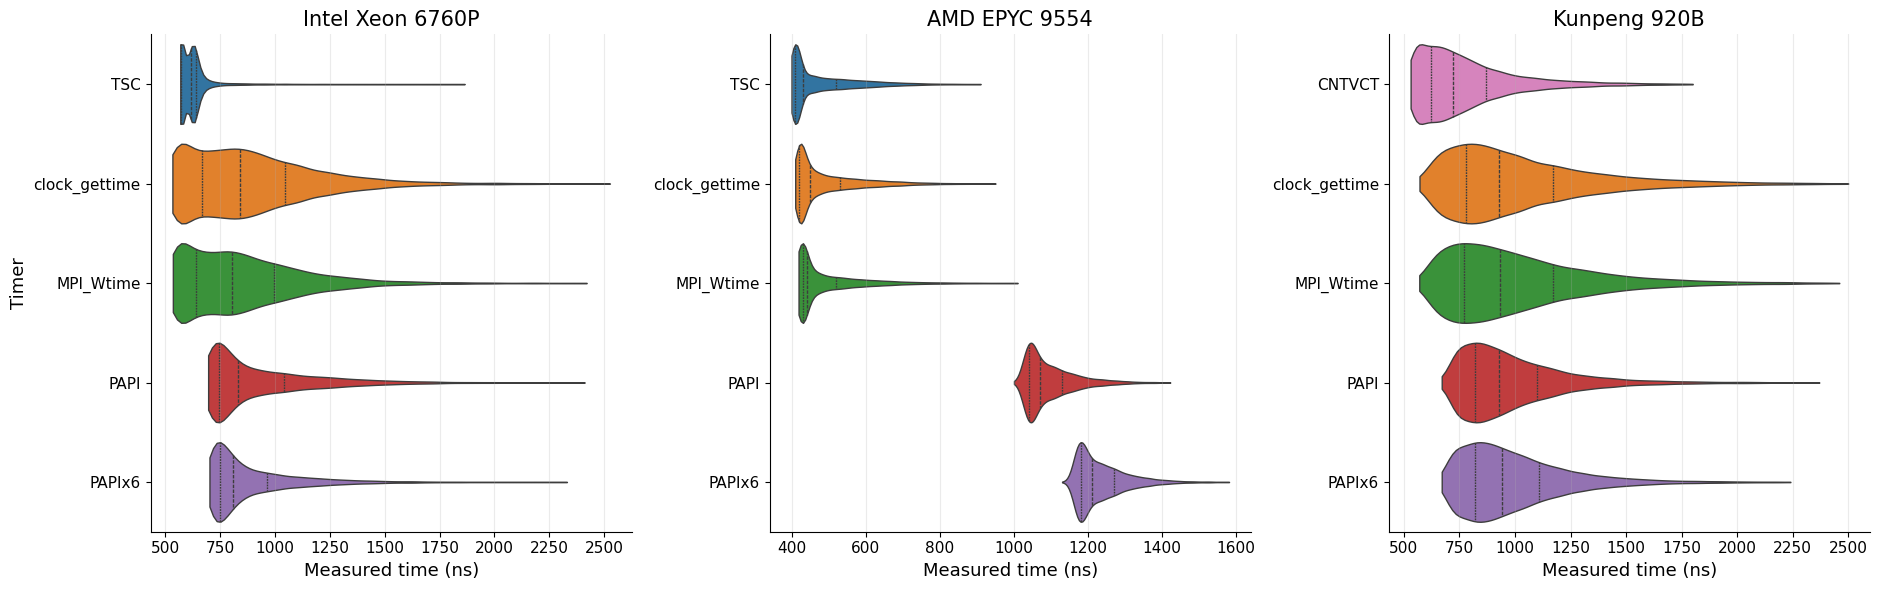

In [5]:
hosts = [h for h in HOSTS if h in set(df_trim['host'])]
fig, axes = plt.subplots(1, len(hosts), figsize=(6.3 * len(hosts), 6), sharey=False)
axes = np.atleast_1d(axes)

for ax, host in zip(axes, hosts):
    host_df = df_trim[df_trim['host'] == host]
    present = [t for t in TIMER_ORDER if t in set(host_df['timer'])]
    order = [timer_label(t) for t in present]
    palette = {timer_label(t): TIMER_COLORS.get(t, '#888888') for t in present}
    sns.violinplot(
        data=host_df, x='ns', y='timer_label', order=order,
        hue='timer_label', hue_order=order, palette=palette, legend=False,
        inner='quart', linewidth=1.0, density_norm='width', cut=0, ax=ax,
    )
    ax.set_title(HOST_NAME_MAP.get(host, host), fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('Measured time (ns)', fontsize=XLABEL_FONTSIZE)
    ax.set_ylabel('Timer' if ax is axes[0] else '', fontsize=YLABEL_FONTSIZE)
    ax.tick_params(axis='x', labelsize=XTICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=YTICK_FONTSIZE)
    ax.grid(True, axis='x', alpha=0.25)

sns.despine()
plt.tight_layout()
out = Path('/astrum/home/hpchzy/code/TacVar/utils') / f'motivation_0616_{KERNEL}_size{SIZE}.png'
fig.savefig(out, dpi=220, bbox_inches='tight')
print('saved:', out)
plt.show()